In [54]:
from langgraph.graph import StateGraph, START, END
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_mistralai import ChatMistralAI, MistralAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.vectorstores import FAISS
from langgraph.graph import StateGraph, START, END
from typing import List, TypedDict, Literal
from langchain_core.documents import Document
from pydantic import BaseModel, Field

from dotenv import load_dotenv
load_dotenv()

True

In [55]:
docs = (
    PyPDFLoader("./documents/Company_Policies.pdf").load()
    + PyPDFLoader("./documents/Company_Profile.pdf").load()
    + PyPDFLoader("./documents/Product_and_Pricing.pdf").load()
)

In [56]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

In [57]:
embeddings = MistralAIEmbeddings()
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

In [58]:
class State(TypedDict):
    question: str
    need_retrieval: bool
    docs: List[Document]
    relevant_docs: List[Document] 
    context: str
    answer: str
    issue: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str]
    retries: int

In [59]:
llm = ChatMistralAI()

In [60]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

should_retrieve_llm = decide_retrieval_prompt | llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: "State"):
    q = state["question"]
    answer = should_retrieve_llm.invoke({
        "question": q
    })
    return {"need_retrieval" : answer.should_retrieve}


In [61]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)

def generate_direct(state: State):
    q = state["question"]
    answer = (direct_generation_prompt | llm).invoke({"question": q})
    return {"answer": answer.content}

In [62]:
def retrieve(state: State):
    q = state['question']
    docs = retriever.invoke(q)
    return {"docs": docs}


class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relevance_llm = is_relevant_prompt | llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):
    q = state["question"]
    relevant_docs: List[Document] = []
    for d in state["docs"]:
        out = relevance_llm.invoke({"question": q, "document": d.page_content})
        if out.is_relevant == True:
            relevant_docs.append(d)

    return {"relevant_docs": relevant_docs}


In [63]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)


def generate_from_context(state: State):
    context = "\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs", [])]
    ).strip()
    if not context:
        return {"answer": "No relevant document found.", "context": ""}
    out = (rag_generation_prompt | llm).invoke({
        "question": state["question"],
        "context": context
    })
    return {"context": context, "answer": out.content}


In [64]:
class IsSUPDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str] = Field(default_factory=list)


issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

issup_llm = llm.with_structured_output(IsSUPDecision)

def is_sup(state: State):
    decision = (issup_prompt | issup_llm).invoke({
        "question": state["question"],
        "answer": state["answer"],
        "context": state["context"]
    })
    return {"issue": decision.issup, "evidence": decision.evidence}

In [65]:
revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)

def revise_answer(state: State):
    out = (revise_prompt | llm).invoke({
        "question": state["question"],
        "answer": state["answer"],
        "context": state["context"]
    })
    return {"answer": out.content, "retries": state.get("retries", 0) + 1}
    

In [66]:
def no_relevant_docs(state: State):
    return {"answer": "No relevant document found.", "context": ""}

In [67]:
MAX_RETRIES = 10

def route_after_issup(state: State) -> Literal["revise_answer", "accept_answer"]:
    if state["issue"] == "fully_supported":
        return "accept_answer"
    if state.get("retries", 0) > MAX_RETRIES:
        return "accept_answer"
    else:
        return "revise_answer"


def accept_answer(state: State):
    return {}

In [68]:
def route_after_decide(state: State):
    if state['need_retrieval'] == True:
        return "retrieve_docs"
    else:
        return "direct_answer"

def route_after_relevance(state: State):
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_context"
    else:
        return "no_result"


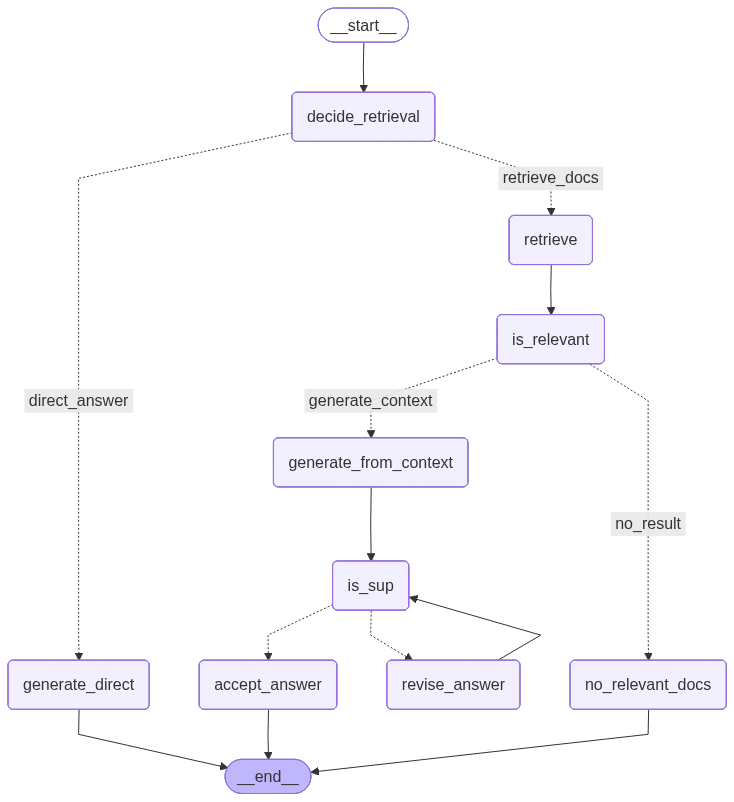

In [69]:
g = StateGraph(State)

g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)
g.add_node("is_relevant", is_relevant)
g.add_node("generate_from_context", generate_from_context)
g.add_node("no_relevant_docs", no_relevant_docs)
g.add_node("is_sup", is_sup)
g.add_node("revise_answer", revise_answer)
g.add_node("accept_answer", accept_answer)

g.add_edge(START, "decide_retrieval")
g.add_conditional_edges("decide_retrieval", route_after_decide, {
    "retrieve_docs": "retrieve", "direct_answer": "generate_direct"
})
g.add_edge("retrieve", "is_relevant")
g.add_conditional_edges("is_relevant", route_after_relevance, {
    "generate_context": "generate_from_context", "no_result": "no_relevant_docs"
})
g.add_edge("generate_from_context", "is_sup")
g.add_conditional_edges("is_sup", route_after_issup, {
    "accept_answer": "accept_answer", "revise_answer": "revise_answer"
})
g.add_edge("revise_answer", "is_sup")
g.add_edge("accept_answer", END)
g.add_edge("generate_direct", END)
g.add_edge("no_relevant_docs", END)


app = g.compile()
app

In [70]:
result = app.invoke({
    "question": "Describe NexaAI’s company culture."
},config={"recursion_limit": 80})


print("need_retrieval:", result.get("need_retrieval"))
print("#docs:", len(result.get("docs", [])))
print("#relevant_docs:", len(result.get("relevant_docs", [])))
print("issue:", result.get("issue"))
print("evidence:", result.get("evidence"))
print("answer:", result.get("answer"))

need_retrieval: True
#docs: 4
#relevant_docs: 2
issup: None
evidence: ['NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.', 'All employment decisions are made without discrimination.', 'Bi-annual performance reviews', 'Clear career progression framework', 'Strict anti-harassment policy']
answer: - NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
- All employment decisions are made without discrimination.
- Bi-annual performance reviews
- Clear career progression framework
- Strict anti-harassment policy
